In [14]:
import pandas as pd
import numpy as np
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import matplotlib.pyplot as plt	
from mpl_toolkits.mplot3d import Axes3D
import random

In [68]:
#make fake comsol data
x_vals = np.random.uniform(-4000, 4000, size=20)
y_vals = np.random.uniform(-4000, 4000, size=20)
z_vals = np.random.uniform(-4000, 4000, size=20)

with open("exStimVoltProf.txt", "w") as f:
    for x in x_vals:
        for y in y_vals:
            for z in z_vals:
                V = x+y+z  # just a made-up smooth voltage profile
                f.write(f"{x:.1f} {y:.1f} {z:.1f} {V:.6f}\n")

In [69]:
column_names = ['x', 'y', 'z', 'V']
df = pd.read_csv('exStimVoltProf.txt', names=column_names, comment='%', delim_whitespace=True)
x = np.array(df.x.to_list())
y = np.array(df.y.to_list())
z = np.array(df.z.to_list())
points = np.array([x,y,z]).T
V = np.array(df.V.to_list())


/tmp/ipykernel_932/2280736489.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('exStimVoltProf.txt', names=column_names, comment='%', delim_whitespace=True)


In [72]:
Vint = LinearNDInterpolator(points, V)

#just get random points
x1 = np.random.uniform(-4000, 4000, size=100)
y1 = np.random.uniform(-4000, 4000, size=100)
z1 = np.random.uniform(-4000, 4000, size=100)

interpolated_values = Vint(np.column_stack((x1, y1, z1)))

'''
print("The original values are:")
print(f"x: {x},\n y: {y},\n z: {z}\n")
print("The interpolated values:")
print(interpolated_values)
'''

'\nprint("The original values are:")\nprint(f"x: {x},\n y: {y},\n z: {z}\n")\nprint("The interpolated values:")\nprint(interpolated_values)\n'

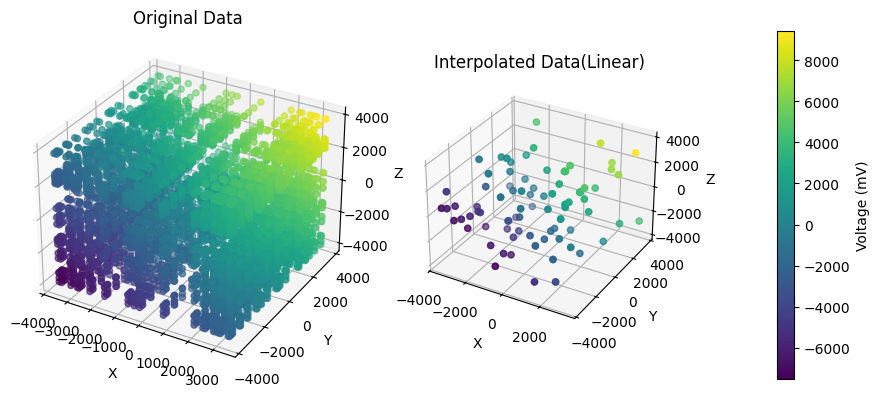

In [73]:
X, Y, Z = x, y, z
X1,Y1,Z1= x1,y1,z1

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("Original Data")
ax1.scatter(X, Y, Z, c=V, cmap='viridis')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')


#interpolated data
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("Interpolated Data(Linear)")
ax2.scatter(X1,Y1,Z1, c=interpolated_values, cmap='viridis')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
plt.tight_layout()

#add a colour bar
cbar = plt.colorbar(ax2.scatter(X1,Y1,Z1, c=interpolated_values, cmap='viridis'), pad=0.25)
cbar.set_label('Voltage (mV)')  # label for the colorbar

plt.ioff()
plt.show()